# Congressional Trading Risk Intelligence
## 02 — Trading Patterns Analysis

This notebook explores trading patterns in cleaned U.S. congressional financial-disclosure data.

### Questions explored
1. What transaction types appear most often?
2. Which lawmakers have the most disclosed transactions?
3. Which sectors and industries appear most frequently?
4. Which tickers are most commonly disclosed?
5. How large are the reported transaction ranges?
6. How does disclosed trading activity change over time?
7. Are there notable differences across parties or states?

> **Important:** Higher trading activity, sector concentration, or transaction value does **not** establish insider trading, unlawful conduct, or an ethics violation. This notebook is descriptive.


## 1. Import libraries

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)


## 2. Load the cleaned dataset

In [2]:
DATA_PATH = Path("../data/processed/us_congress_trades_clean.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["disclosure_date", "transaction_date"]
)

print(f"Rows: {len(df):,}")
print(f"Unique lawmakers: {df['representative'].nunique():,}")
print(f"Date range: {df['transaction_date'].min().date()} to {df['transaction_date'].max().date()}")
df.head()


Rows: 16,616
Unique lawmakers: 196
Date range: 2012-06-19 to 2023-12-22


,disclosure_year,disclosure_date,transaction_date,owner,ticker,asset_description,type,amount,representative,district,state,ptr_link,cap_gains_over_200_usd,industry,sector,party,amount_min,amount_max,amount_midpoint,disclosure_lag_days
0,2021,2021-10-04,2021-09-27,joint,BP,BP plc,purchase,"$1,001 - $15,000",Virginia Foxx,NC05,NC,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2021/20019557.pdf,False,Integrated oil Companies,Energy,Republican,1001.0,15000.0,8000.5,7.0
1,2021,2021-10-04,2021-09-13,joint,XOM,Exxon Mobil Corporation,purchase,"$1,001 - $15,000",Virginia Foxx,NC05,NC,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2021/20019557.pdf,False,Integrated oil Companies,Energy,Republican,1001.0,15000.0,8000.5,21.0
2,2021,2021-10-04,2021-09-10,joint,ILPT,Industrial Logistics Properties Trust - Common Shares of Beneficial Interest,purchase,"$15,001 - $50,000",Virginia Foxx,NC05,NC,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2021/20019557.pdf,False,Real Estate Investment Trusts,Real Estate,Republican,15001.0,50000.0,32500.5,24.0
3,2021,2021-10-04,2021-09-28,joint,PM,Phillip Morris International Inc,purchase,"$15,001 - $50,000",Virginia Foxx,NC05,NC,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2021/20019557.pdf,False,Farming/Seeds/Milling,Consumer Non-Durables,Republican,15001.0,50000.0,32500.5,6.0
4,2021,2021-10-04,2021-09-17,self,BLK,BlackRock Inc,sale_partial,"$1,001 - $15,000",Alan S. Lowenthal,CA47,CA,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2021/20019570.pdf,False,Investment Bankers/Brokers/Service,Finance,Democrat,1001.0,15000.0,8000.5,17.0


## 3. Transaction-type distribution

In [3]:
transaction_counts = (
    df["type"]
    .value_counts()
    .rename_axis("Transaction_Type")
    .reset_index(name="Count")
)

transaction_counts["Share_Percent"] = (
    transaction_counts["Count"] / len(df) * 100
).round(1)

transaction_counts


,Transaction_Type,Count,Share_Percent
0,purchase,8685,52.3
1,sale_full,5279,31.8
2,sale_partial,2521,15.2
3,exchange,130,0.8
4,sale,1,0.0


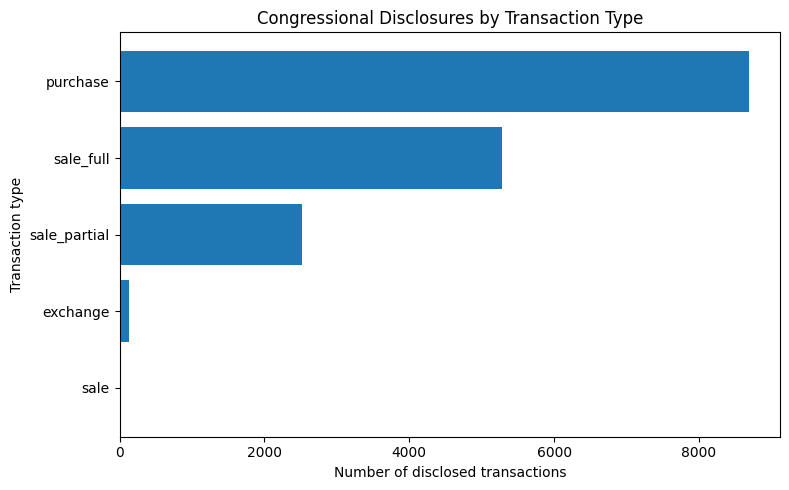

In [4]:
plot_data = transaction_counts.sort_values("Count")

plt.figure(figsize=(8, 5))
plt.barh(plot_data["Transaction_Type"], plot_data["Count"])
plt.title("Congressional Disclosures by Transaction Type")
plt.xlabel("Number of disclosed transactions")
plt.ylabel("Transaction type")
plt.tight_layout()
plt.show()


### Interpretation

This view shows the composition of disclosed transactions in the dataset. It does not indicate whether one transaction type is more problematic than another.


## 4. Lawmakers with the most disclosed transactions

In [5]:
representative_counts = (
    df["representative"]
    .value_counts()
    .rename_axis("Representative")
    .reset_index(name="Transaction_Count")
)

representative_counts.head(15)


,Representative,Transaction_Count
0,Josh Gottheimer,1414
1,Gilbert Cisneros,782
2,"Donald S. Beyer, Jr.",757
3,Susie Lee,696
4,Alan S. Lowenthal,625
5,Mark E. Green,588
6,Donna Shalala,566
7,Kevin Hern,537
8,Dean Phillips,512
9,Lois Frankel,483


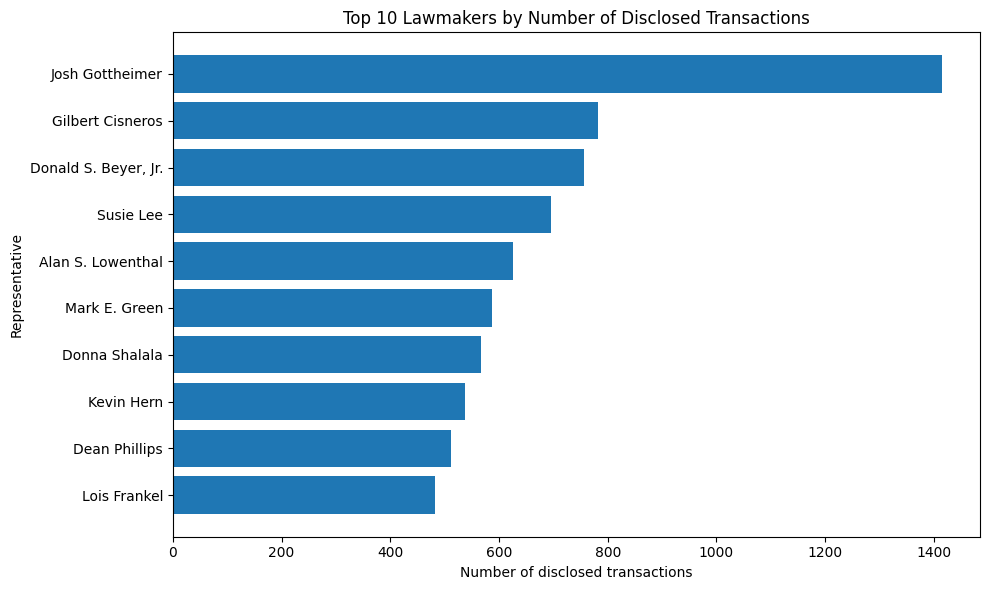

In [6]:
top_representatives = representative_counts.head(10).sort_values("Transaction_Count")

plt.figure(figsize=(10, 6))
plt.barh(
    top_representatives["Representative"],
    top_representatives["Transaction_Count"]
)
plt.title("Top 10 Lawmakers by Number of Disclosed Transactions")
plt.xlabel("Number of disclosed transactions")
plt.ylabel("Representative")
plt.tight_layout()
plt.show()


### Interpretation

A high transaction count reflects greater disclosed trading activity in this dataset. It should not be treated as evidence of improper conduct.


## 5. Sector exposure

In [7]:
sector_counts = (
    df["sector"]
    .value_counts()
    .rename_axis("Sector")
    .reset_index(name="Transaction_Count")
)

sector_counts.head(15)


,Sector,Transaction_Count
0,Technology,2387
1,Health Care,1570
2,Finance,1412
3,Consumer Services,1321
4,Energy,850
5,Consumer Discretionary,744
6,Capital Goods,712
7,Public Utilities,675
8,Consumer Non-Durables,481
9,Miscellaneous,425


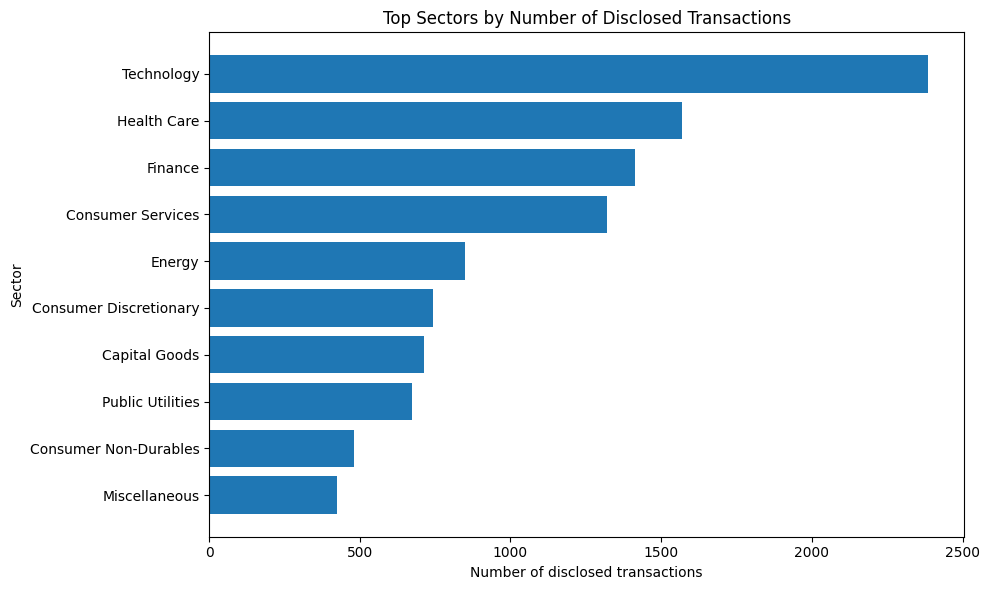

In [8]:
top_sectors = sector_counts.head(10).sort_values("Transaction_Count")

plt.figure(figsize=(10, 6))
plt.barh(top_sectors["Sector"], top_sectors["Transaction_Count"])
plt.title("Top Sectors by Number of Disclosed Transactions")
plt.xlabel("Number of disclosed transactions")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()


## 6. Industry concentration

In [9]:
industry_counts = (
    df["industry"]
    .value_counts()
    .rename_axis("Industry")
    .reset_index(name="Transaction_Count")
)

industry_counts.head(15)


,Industry,Transaction_Count
0,Computer Software: Prepackaged Software,714
1,Major Banks,499
2,Business Services,489
3,Major Pharmaceuticals,427
4,Natural Gas Distribution,408
5,Real Estate Investment Trusts,393
6,Industrial Machinery/Components,387
7,Semiconductors,383
8,"Computer Software: Programming, Data Processing",346
9,Oil & Gas Production,268


## 7. Most frequently disclosed tickers

In [10]:
ticker_counts = (
    df["ticker"]
    .dropna()
    .value_counts()
    .rename_axis("Ticker")
    .reset_index(name="Transaction_Count")
)

ticker_counts.head(15)


,Ticker,Transaction_Count
0,MSFT,259
1,AAPL,189
2,NTAP,125
3,TDDXX,122
4,FB,122
5,AMZN,113
6,TSLA,104
7,BRK.B,101
8,NVDA,101
9,JPM,85


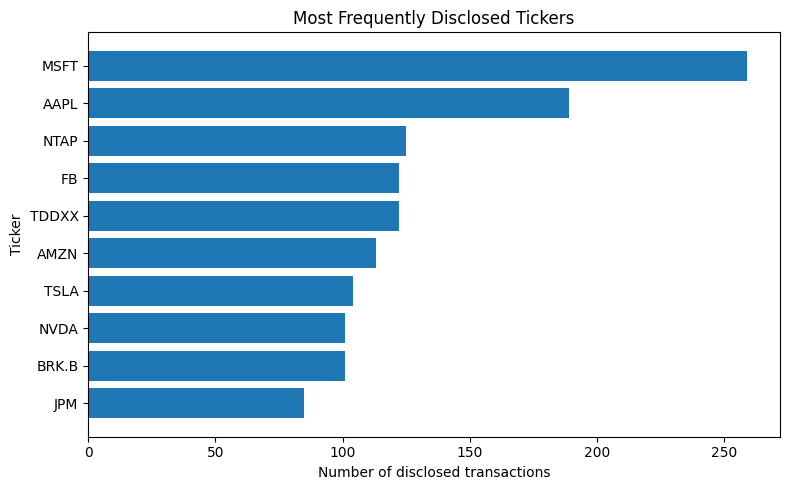

In [11]:
top_tickers = ticker_counts.head(10).sort_values("Transaction_Count")

plt.figure(figsize=(8, 5))
plt.barh(top_tickers["Ticker"], top_tickers["Transaction_Count"])
plt.title("Most Frequently Disclosed Tickers")
plt.xlabel("Number of disclosed transactions")
plt.ylabel("Ticker")
plt.tight_layout()
plt.show()


## 8. Transaction-size analysis

Congressional disclosures generally provide amount **ranges**, not exact transaction values. This project therefore uses `amount_midpoint` only as an analytical approximation.

It should not be interpreted as the actual value of a transaction.


In [12]:
amount_summary = df["amount_midpoint"].describe().to_frame("Amount_Midpoint")
amount_summary


,Amount_Midpoint
count,1.661600e+04
mean,6.012659e+04
std,5.604428e+05
min,1.001000e+03
25%,8.000500e+03
50%,8.000500e+03
75%,3.250050e+04
max,5.000000e+07


In [13]:
amount_by_rep = (
    df.groupby("representative", dropna=False)
    .agg(
        Transaction_Count=("representative", "size"),
        Estimated_Midpoint_Total=("amount_midpoint", "sum"),
        Estimated_Midpoint_Average=("amount_midpoint", "mean")
    )
    .reset_index()
    .sort_values("Estimated_Midpoint_Total", ascending=False)
)

amount_by_rep.head(10)


,representative,Transaction_Count,Estimated_Midpoint_Total,Estimated_Midpoint_Average
174,Suzan K. DelBene,221,155690110.5,7.044801e+05
99,Josh Gottheimer,1414,112570207.0,7.961118e+04
108,Kevin Hern,537,97970768.0,1.824409e+05
138,Nancy Pelosi,91,88680546.5,9.745115e+05
121,Mark E. Green,588,84071794.0,1.429792e+05
161,Scott H. Peters,124,50945554.0,4.108512e+05
129,Michael T. McCaul,391,33132195.5,8.473707e+04
72,Greg Gianforte,481,25202740.5,5.239655e+04
50,"Donald S. Beyer, Jr.",757,18098378.5,2.390803e+04
130,Michael Waltz,4,15815002.0,3.953750e+06


### Interpretation caution

The totals above are **estimated midpoint aggregates** derived from disclosure ranges. They are useful for comparative analytics but are not exact dollar totals.


## 9. Trading activity over time

In [14]:
monthly_activity = (
    df.assign(
        Month=df["transaction_date"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby("Month")
    .size()
    .reset_index(name="Transaction_Count")
)

monthly_activity.tail(12)


,Month,Transaction_Count
52,2022-07-01,181
53,2022-08-01,223
54,2022-09-01,232
55,2022-10-01,224
56,2022-11-01,330
57,2022-12-01,197
58,2023-01-01,272
59,2023-02-01,193
60,2023-03-01,155
61,2023-04-01,52


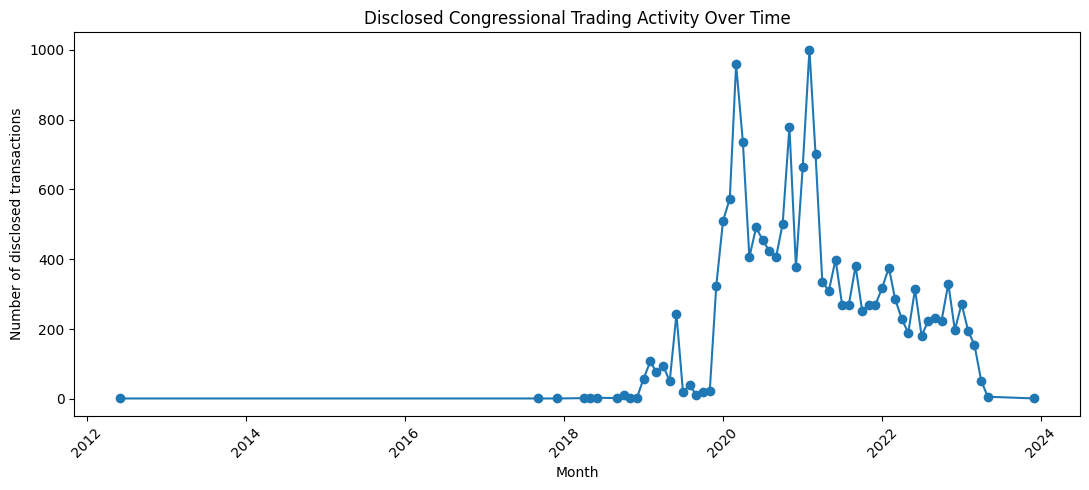

In [15]:
plt.figure(figsize=(11, 5))
plt.plot(
    monthly_activity["Month"],
    monthly_activity["Transaction_Count"],
    marker="o"
)
plt.title("Disclosed Congressional Trading Activity Over Time")
plt.xlabel("Month")
plt.ylabel("Number of disclosed transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 10. Party-level patterns

In [16]:
party_summary = (
    df.groupby("party", dropna=False)
    .agg(
        Transaction_Count=("representative", "size"),
        Unique_Lawmakers=("representative", "nunique"),
        Estimated_Midpoint_Total=("amount_midpoint", "sum")
    )
    .reset_index()
)

party_summary


,party,Transaction_Count,Unique_Lawmakers,Estimated_Midpoint_Total
0,Democrat,10169,87,588314170.0
1,Jackson,14,1,691007.0
2,Libertarian,2,1,40501.0
3,Republican,6353,99,408326180.5
4,NaN,78,8,1691539.0


In [17]:
party_type = pd.crosstab(df["party"], df["type"])
party_type


type,exchange,purchase,sale,sale_full,sale_partial
party,,,,,
Democrat,64,4907,0,3228,1970
Jackson,0,4,0,1,9
Libertarian,0,2,0,0,0
Republican,66,3740,1,2011,535


### Interpretation

Party-level totals should be interpreted carefully because the number of lawmakers represented in the dataset may differ by party. Raw totals therefore do not automatically imply different trading behavior at the individual-law-maker level.


## 11. State-level activity

In [18]:
state_summary = (
    df.groupby("state", dropna=False)
    .agg(
        Transaction_Count=("representative", "size"),
        Unique_Lawmakers=("representative", "nunique")
    )
    .reset_index()
    .sort_values("Transaction_Count", ascending=False)
)

state_summary.head(15)


,state,Transaction_Count,Unique_Lawmakers
3,CA,2290,18
28,NJ,1730,6
7,FL,1521,17
40,TX,1096,12
42,VA,990,7
39,TN,890,8
26,NC,802,12
30,NV,696,1
34,OR,674,3
33,OK,543,3


## 12. Compact analytics summary

In [19]:
summary = pd.DataFrame({
    "Metric": [
        "Cleaned transactions",
        "Unique lawmakers",
        "Most common transaction type",
        "Most active disclosed trader",
        "Most represented sector",
        "Most frequently disclosed ticker"
    ],
    "Value": [
        len(df),
        df["representative"].nunique(),
        df["type"].value_counts().idxmax(),
        df["representative"].value_counts().idxmax(),
        df["sector"].value_counts().idxmax(),
        df["ticker"].dropna().value_counts().idxmax()
    ]
})

summary


,Metric,Value
0,Cleaned transactions,16616
1,Unique lawmakers,196
2,Most common transaction type,purchase
3,Most active disclosed trader,Josh Gottheimer
4,Most represented sector,Technology
5,Most frequently disclosed ticker,MSFT


## Exploratory findings

This notebook establishes a descriptive baseline for congressional trading activity in the dataset:

- trading activity is concentrated among a subset of lawmakers;
- certain sectors and tickers appear substantially more often than others;
- transaction-size ranges can be converted into approximate analytical features, while preserving the distinction between estimates and exact values;
- trading activity varies over time;
- party- and state-level comparisons require normalization before drawing stronger conclusions.

### Next notebook

**03 — Disclosure Compliance Analysis**

The next stage will focus on the time between `transaction_date` and `disclosure_date`.

That notebook will examine reporting delays and, after reviewing the applicable congressional disclosure rules, distinguish between:
- descriptive delay;
- potentially late disclosure; and
- cases where the available data is insufficient to draw a compliance conclusion.
